<a href="https://colab.research.google.com/github/WTavasi/MataPredict/blob/main/ML_GroupProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 - Install all dependencies
!pip install pandas numpy scikit-learn requests tqdm kaggle -q

In [ ]:
# Cell 2 - Load and inspect all Zindi files
# Upload the zip from Zindi when prompted, or upload the extracted CSVs directly

from google.colab import files
import pandas as pd
import zipfile
import io
import os

# Upload the zip file
print("Upload the Zindi zip file (traffic-jam-predicting-peoples-movement-into-nairobi...zip)")
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

# Extract outer zip
with zipfile.ZipFile(io.BytesIO(uploaded[zip_filename])) as outer_zip:
    outer_zip.extractall("/content/zindi_raw/")

# The train data is nested inside a second zip
inner_zip_path = "/content/zindi_raw/train_revised_11.09.2018.zip"
with zipfile.ZipFile(inner_zip_path) as inner_zip:
    inner_zip.extractall("/content/zindi_raw/")

# Load all three files
train_df = pd.read_csv("/content/zindi_raw/train_revised.csv")
test_df  = pd.read_csv("/content/zindi_raw/test_questions.csv")
sub_df   = pd.read_csv("/content/zindi_raw/sample_submission.csv")

print(f"Train shape:  {train_df.shape}  — one row per ticket sold")
print(f"Test shape:   {test_df.shape}   — one row per ride (no tickets)")
print(f"Sample sub:   {sub_df.shape}    — target format: ride_id + number_of_ticket")
print()
print(train_df.head(3).to_string())

Upload the Zindi zip file (traffic-jam-predicting-peoples-movement-into-nairobi...zip)


Saving traffic-jam-predicting-peoples-movement-into-nairobi20250307-26022-9b8vw1.zip to traffic-jam-predicting-peoples-movement-into-nairobi20250307-26022-9b8vw1 (2).zip
Train shape:  (51645, 10)  — one row per ticket sold
Test shape:   (1111, 7)   — one row per ride (no tickets)
Sample sub:   (1111, 2)    — target format: ride_id + number_of_ticket

   ride_id seat_number payment_method payment_receipt travel_date travel_time travel_from travel_to car_type  max_capacity
0     1442         15A          Mpesa      UZUEHCBUSO    17-10-17        7:15      Migori   Nairobi      Bus            49
1     5437         14A          Mpesa      TIHLBUSGTE    19-11-17        7:12      Migori   Nairobi      Bus            49
2     5710          8B          Mpesa      EQX8Q5G19O    26-11-17        7:05      Keroka   Nairobi      Bus            49


In [ ]:
# Cell 3 - Aggregate tickets per ride and engineer features
# This converts the ticket-level data into ride-level data
# which is the correct granularity for your ML model

import pandas as pd

# --- Parse timestamps ---
train_df["travel_datetime"] = pd.to_datetime(
    train_df["travel_date"].astype(str) + " " + train_df["travel_time"].astype(str),
    format="%d-%m-%y %H:%M",
    errors="coerce"
)

# Verify parsing worked
bad_timestamps = train_df["travel_datetime"].isnull().sum()
print(f"Unparseable timestamps: {bad_timestamps}")
train_df = train_df.dropna(subset=["travel_datetime"])

# --- Aggregate from ticket level to ride level ---
seats_per_ride = (
    train_df.groupby("ride_id")
    .agg(
        seats_sold      = ("seat_number",   "count"),
        max_capacity    = ("max_capacity",  "first"),
        travel_from     = ("travel_from",   "first"),
        travel_to       = ("travel_to",     "first"),
        travel_datetime = ("travel_datetime","first"),
        car_type        = ("car_type",      "first"),
        payment_method  = ("payment_method","first")
    )
    .reset_index()
)

# --- Time features ---
seats_per_ride["hour"]        = seats_per_ride["travel_datetime"].dt.hour
seats_per_ride["minute"]      = seats_per_ride["travel_datetime"].dt.minute
seats_per_ride["day_of_week"] = seats_per_ride["travel_datetime"].dt.day_name()
seats_per_ride["month"]       = seats_per_ride["travel_datetime"].dt.month
seats_per_ride["timestamp_bin"] = seats_per_ride["travel_datetime"].dt.round("30min")

# Peak hours: 5am-9am (morning), 4pm-8pm (evening)
seats_per_ride["is_peak"] = seats_per_ride["hour"].apply(
    lambda h: 1 if (5 <= h <= 9) or (16 <= h <= 20) else 0
)

# --- Overcrowding target ---
# occupancy_rate = proportion of seats filled per ride
seats_per_ride["occupancy_rate"] = (
    seats_per_ride["seats_sold"] / seats_per_ride["max_capacity"]
)

# Binary label: overcrowded if >= 80% full
seats_per_ride["is_overcrowded"] = (
    seats_per_ride["occupancy_rate"] >= 0.8
).astype(int)

# --- Drop travel_to (always Nairobi, zero variance) ---
seats_per_ride = seats_per_ride.drop(columns=["travel_to"])

# --- Map origin towns to Nairobi entry corridor ---
# All these towns route into Nairobi via one of two major roads
corridor_map = {
    "Kisii":     "Mombasa Road",
    "Migori":    "Mombasa Road",
    "Sirare":    "Mombasa Road",
    "Rongo":     "Mombasa Road",
    "Kehancha":  "Mombasa Road",
    "Awendo":    "Mombasa Road",
    "Nyachenge": "Mombasa Road",
    "Homa Bay":  "Langata Road",
    "Mbita":     "Langata Road",
    "Kendu Bay": "Langata Road",
    "Keroka":    "Ngong Road",
    "Keumbu":    "Ngong Road",
    "Kijauri":   "Thika Road",
    "Sori":      "Thika Road"
}
seats_per_ride["route"] = seats_per_ride["travel_from"].map(corridor_map).fillna("unknown")

# --- Summary ---
print(f"\nRide-level dataset shape: {seats_per_ride.shape}")
print(f"Overcrowding rate: {seats_per_ride['is_overcrowded'].mean():.2%}")
print(f"\nCar type breakdown:\n{seats_per_ride['car_type'].value_counts()}")
print(f"\nRoute distribution:\n{seats_per_ride['route'].value_counts()}")
print(f"\nOccupancy rate stats:\n{seats_per_ride['occupancy_rate'].describe()}")
print()
print(seats_per_ride.head(5).to_string())

Unparseable timestamps: 0

Ride-level dataset shape: (6249, 16)
Overcrowding rate: 23.04%

Car type breakdown:
car_type
Bus        3189
shuttle    3060
Name: count, dtype: int64

Route distribution:
route
Mombasa Road    4888
Thika Road       576
Langata Road     378
Ngong Road       332
unknown           75
Name: count, dtype: int64

Occupancy rate stats:
count    6249.000000
mean        0.390467
std         0.359722
min         0.020408
25%         0.090909
50%         0.224490
75%         0.727273
max         1.090909
Name: occupancy_rate, dtype: float64

   ride_id  seats_sold  max_capacity travel_from     travel_datetime car_type payment_method  hour  minute day_of_week  month       timestamp_bin  is_peak  occupancy_rate  is_overcrowded         route
0     1442           1            49      Migori 2017-10-17 07:15:00      Bus          Mpesa     7      15     Tuesday     10 2017-10-17 07:00:00        1        0.020408               0  Mombasa Road
1     5437           1           

In [ ]:
# Cell 4 - Load Digital Matatus GIS shapefiles
# Upload GIS_DATA_2019.zip when prompted

from google.colab import files
import zipfile
import io
import os

print("Upload GIS_DATA_2019.zip from the Digital Matatus project")
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(io.BytesIO(uploaded[zip_filename])) as z:
    z.extractall("/content/gis_data/")

print("Extracted files:", os.listdir("/content/gis_data/"))

Upload GIS_DATA_2019.zip from the Digital Matatus project


Saving GIS_DATA_2019.zip to GIS_DATA_2019 (1).zip
Extracted files: ['shapes.prj', 'shapes.dbf', 'stops.cpg', 'stops.dbf', 'shapes.shx', 'README.txt', 'stops.qpj', 'shapes.shp', 'shapes.qpj', 'stops.shx', 'stops.shp', 'shapes.cpg', 'stops.prj']


In [ ]:
# Cell 4b - Install geopandas and load both shapefiles

!pip install geopandas -q

import geopandas as gpd
import pandas as pd

shapes_gdf = gpd.read_file("/content/gis_data/shapes.shp")
stops_gdf  = gpd.read_file("/content/gis_data/stops.shp")

print(f"Routes (shapes): {shapes_gdf.shape[0]} polylines, {shapes_gdf['route_name'].nunique()} unique routes")
print(f"Stops:           {stops_gdf.shape[0]} stop points")
print(f"CRS:             {shapes_gdf.crs}  (no reprojection needed)")
print()
print("Sample routes:")
print(shapes_gdf[["route_name","route_long","headsign","direction"]].head(10).to_string())

Routes (shapes): 272 polylines, 136 unique routes
Stops:           4284 stop points
CRS:             EPSG:4326  (no reprojection needed)

Sample routes:
  route_name                      route_long  headsign  direction
0        106            Koja-UN-Ruaka-Banana      Koja          0
1        106            Koja-UN-Ruaka-Banana    Banana          1
2        107         Odeon-UN-Ruaka-Ndenderu     Odeon          0
3        107         Odeon-UN-Ruaka-Ndenderu  Ndenderu          1
4        108  UN-New Muthaiga-Gachie-Gichagi      UNEP          0
5        108  UN-New Muthaiga-Gachie-Gichagi   Gichagi          1
6       114R     Ngara-Rwaka-Ndenderu-Limuru     Ngara          0
7       114R     Ngara-Rwaka-Ndenderu-Limuru    Limuru          1
8        116        Koja-Ngara-Banana-Limuru      Koja          0
9        116        Koja-Ngara-Banana-Limuru    Limuru          1


In [ ]:
# Cell 4c - Tag each route with its Nairobi corridor
# We match route_long names to the six major corridors
# This is the bridge between Digital Matatus route geometry
# and the corridor labels we assigned in the Zindi data

corridor_keywords = {
    "Ngong Road":   ["ngong","dagoretti","kawangware","rongai","kibera","langata"],
    "Thika Road":   ["thika","kasarani","ruiru","githurai","roysambu","membley"],
    "Waiyaki Way":  ["waiyaki","westlands","kangemi","uthiru","mountainview","regen"],
    "Jogoo Road":   ["jogoo","umoja","eastlands","donholm","embakasi"],
    "Mombasa Road": ["mombasa","mlolongo","athi","syokimau","imara","south b"],
    "Langata Road": ["langata","karen","bomas","hardy","wilson"]
}

def tag_corridor(route_long):
    if not isinstance(route_long, str):
        return "other"
    text = route_long.lower()
    for corridor, keywords in corridor_keywords.items():
        if any(kw in text for kw in keywords):
            return corridor
    return "other"

shapes_gdf["corridor"] = shapes_gdf["route_long"].apply(tag_corridor)

print("Routes per corridor:")
print(shapes_gdf["corridor"].value_counts().to_string())

Routes per corridor:
corridor
other           116
Ngong Road       40
Jogoo Road       38
Thika Road       34
Waiyaki Way      24
Mombasa Road     16
Langata Road      4


In [ ]:
# Cell 4d - Extract corridor summary: bounding box and stop density per corridor
# This gives each corridor a geographic footprint
# which we will use as a reference feature during visualization

import numpy as np

# Get the geometry bounds per corridor (min/max lat/lon)
corridor_bounds = (
    shapes_gdf.groupby("corridor")
    .agg(
        route_count  = ("route_name", "nunique"),
        min_lat      = ("geometry",   lambda g: g.bounds["miny"].min()),
        max_lat      = ("geometry",   lambda g: g.bounds["maxy"].max()),
        min_lon      = ("geometry",   lambda g: g.bounds["minx"].min()),
        max_lon      = ("geometry",   lambda g: g.bounds["maxx"].max()),
    )
    .reset_index()
)

# Compute centroid per corridor
corridor_bounds["centroid_lat"] = (corridor_bounds["min_lat"] + corridor_bounds["max_lat"]) / 2
corridor_bounds["centroid_lon"] = (corridor_bounds["min_lon"] + corridor_bounds["max_lon"]) / 2

print("Corridor geographic summary:")
print(corridor_bounds.to_string())

# Save for later use in visualization
corridor_bounds.to_csv("/content/corridor_bounds.csv", index=False)

Corridor geographic summary:
       corridor  route_count   min_lat   max_lat    min_lon    max_lon  centroid_lat  centroid_lon
0    Jogoo Road           19 -1.348250 -1.248715  36.820217  36.996873     -1.298482     36.908545
1  Langata Road            2 -1.365610 -1.286082  36.707114  36.827778     -1.325846     36.767446
2  Mombasa Road            8 -1.477248 -1.283131  36.802869  36.989681     -1.380190     36.896275
3    Ngong Road           20 -1.430452 -1.219091  36.655353  36.830383     -1.324771     36.742868
4    Thika Road           17 -1.329979 -1.033820  36.779265  37.078487     -1.181899     36.928876
5   Waiyaki Way           12 -1.291859 -1.105596  36.629578  36.830973     -1.198728     36.730276
6         other           58 -1.338996 -1.056380  36.641678  36.996878     -1.197688     36.819278


In [ ]:
# Cell 4e - Extract stop-level data as a flat CSV reference
# stop_lat, stop_lon, trip_count are the useful columns for the project

stops_clean = stops_gdf[["stop_id","stop_name","stop_lat","stop_lon","trip_count"]].copy()
stops_clean = stops_clean.dropna(subset=["stop_lat","stop_lon"])

# Tag stops with corridor using the same keyword logic on stop names
def tag_stop_corridor(name):
    if not isinstance(name, str):
        return "other"
    name = name.lower()
    for corridor, keywords in corridor_keywords.items():
        if any(kw in name for kw in keywords):
            return corridor
    return "other"

stops_clean["corridor"] = stops_clean["stop_name"].apply(tag_stop_corridor)

print(f"Clean stops: {stops_clean.shape}")
print(stops_clean.head(10).to_string())

stops_clean.to_csv("/content/digital_matatus_stops.csv", index=False)
print("\nSaved to /content/digital_matatus_stops.csv")

Clean stops: (4284, 6)
   stop_id            stop_name  stop_lat   stop_lon  trip_count corridor
0  0001RLW             Railways -1.290884  36.828242          14    other
1  0002KOJ                 Koja -1.281230  36.822596           0    other
2  0003NGR                Ngara -1.274395  36.823806           0    other
3  0004ODN                Odeon -1.282769  36.825032           0    other
4  0005AMB   Kencom/Ambassadeur -1.285963  36.826048           0    other
5  0006BSS          Bus Station -1.287191  36.828881           0    other
6  0007COM           Commercial -1.284282  36.826188           0    other
7  0008MUT             Muthurwa -1.288049  36.833947           0    other
8  0010OTC                  OTC -1.284947  36.830994           0    other
9  0011TUS  Tusker/Ronald Ngala -1.285346  36.828574           0    other

Saved to /content/digital_matatus_stops.csv


In [ ]:
# Cell 5 - Load and profile the Waze dataset
# This dataset characterises general urban driver behaviour.
# It is a user-level engagement dataset with no timestamps or
# route data, so it is used as a behavioural reference rather
# than a direct merge target.

from google.colab import files
import pandas as pd
import io

print("Upload waze_dataset.csv from Kaggle")
uploaded = files.upload()

waze_df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print(f"Shape: {waze_df.shape}")
print(f"\nColumns: {list(waze_df.columns)}")
print(f"\nNull counts:\n{waze_df.isnull().sum()}")
print(f"\nLabel distribution:\n{waze_df['label'].value_counts()}")

Upload waze_dataset.csv from Kaggle


Saving waze_dataset.csv to waze_dataset (1).csv
Shape: (14999, 13)

Columns: ['ID', 'label', 'sessions', 'drives', 'total_sessions', 'n_days_after_onboarding', 'total_navigations_fav1', 'total_navigations_fav2', 'driven_km_drives', 'duration_minutes_drives', 'activity_days', 'driving_days', 'device']

Null counts:
ID                           0
label                      700
sessions                     0
drives                       0
total_sessions               0
n_days_after_onboarding      0
total_navigations_fav1       0
total_navigations_fav2       0
driven_km_drives             0
duration_minutes_drives      0
activity_days                0
driving_days                 0
device                       0
dtype: int64

Label distribution:
label
retained    11763
churned      2536
Name: count, dtype: int64


In [ ]:
# Cell 5b - Clean and derive behavioural reference features

# Drop rows where label is null (700 rows have no churn label)
waze_clean = waze_df.dropna(subset=["label"]).copy()
print(f"After dropping unlabelled rows: {waze_clean.shape}")

# Derive meaningful aggregate features
waze_clean["km_per_drive"] = (
    waze_clean["driven_km_drives"] / waze_clean["drives"].replace(0, pd.NA)
)
waze_clean["drive_intensity_ratio"] = (
    waze_clean["driving_days"] / waze_clean["activity_days"].replace(0, pd.NA)
)
waze_clean["sessions_per_day"] = (
    waze_clean["sessions"] / waze_clean["activity_days"].replace(0, pd.NA)
)

# Fill derived NaNs caused by zero denominators
waze_clean["km_per_drive"]          = waze_clean["km_per_drive"].fillna(0)
waze_clean["drive_intensity_ratio"] = waze_clean["drive_intensity_ratio"].fillna(0)
waze_clean["sessions_per_day"]      = waze_clean["sessions_per_day"].fillna(0)

print(f"\nDerived feature stats:")
print(waze_clean[["km_per_drive","drive_intensity_ratio","sessions_per_day"]].describe().to_string())

After dropping unlabelled rows: (14299, 13)

Derived feature stats:
       km_per_drive  drive_intensity_ratio  sessions_per_day
count  14299.000000           14299.000000      14299.000000
mean     232.269197               0.735071         10.258022
std      616.197409               0.273400         22.523488
min        0.000000               0.000000          0.000000
25%       32.486524               0.631579          1.500000
50%       72.947059               0.800000          3.960000
75%      179.347527               0.960000          9.400000
max    15777.426560               1.000000        479.000000


/tmp/ipykernel_1902/2110309150.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  waze_clean["km_per_drive"]          = waze_clean["km_per_drive"].fillna(0)
/tmp/ipykernel_1902/2110309150.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  waze_clean["drive_intensity_ratio"] = waze_clean["drive_intensity_ratio"].fillna(0)
/tmp/ipykernel_1902/2110309150.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future

In [ ]:
# Cell 5c - Extract dataset-level behavioural constants
# These are used as reference statistics in your methodology
# and in the visualisation section, not as row-level features

waze_stats = {
    "avg_km_per_drive":          waze_clean["km_per_drive"].mean(),
    "median_km_per_drive":       waze_clean["km_per_drive"].median(),
    "avg_drive_intensity":       waze_clean["drive_intensity_ratio"].mean(),
    "avg_driving_days_per_month":waze_clean["driving_days"].mean(),
    "churn_rate":                (waze_clean["label"] == "churned").mean(),
    "iphone_share":              (waze_clean["device"] == "iPhone").mean(),
}

print("Waze behavioural reference constants:")
for k, v in waze_stats.items():
    print(f"  {k}: {v:.4f}")

# Save cleaned Waze data for the visualisation cells
waze_clean.to_csv("/content/waze_clean.csv", index=False)
print("\nSaved to /content/waze_clean.csv")

Waze behavioural reference constants:
  avg_km_per_drive: 232.2692
  median_km_per_drive: 72.9471
  avg_drive_intensity: 0.7351
  avg_driving_days_per_month: 12.1825
  churn_rate: 0.1774
  iphone_share: 0.6452

Saved to /content/waze_clean.csv


In [ ]:
# Cell 6 - Merge Zindi ride data with Digital Matatus corridor bounds

import pandas as pd

corridor_bounds = pd.read_csv("/content/corridor_bounds.csv")

df_merged = pd.merge(
    seats_per_ride,
    corridor_bounds[["corridor", "route_count", "centroid_lat", "centroid_lon"]],
    left_on="route",
    right_on="corridor",
    how="left"
)

df_merged = df_merged.drop(columns=["corridor"])
df_merged["gis_missing"] = df_merged["centroid_lat"].isna()

# Fill the 75 unknown rows
df_merged["route_count"]  = df_merged["route_count"].fillna(0)
df_merged["centroid_lat"] = df_merged["centroid_lat"].fillna(df_merged["centroid_lat"].median())
df_merged["centroid_lon"] = df_merged["centroid_lon"].fillna(df_merged["centroid_lon"].median())

# Build df_final here so Cell 7 can access it
final_columns = [
    "ride_id", "route", "travel_from", "timestamp_bin",
    "hour", "minute", "day_of_week", "month",
    "car_type", "payment_method", "is_peak",
    "seats_sold", "max_capacity", "occupancy_rate", "is_overcrowded",
    "route_count", "centroid_lat", "centroid_lon", "gis_missing"
]

df_final = (
    df_merged[final_columns]
    .drop_duplicates()
    .sort_values("timestamp_bin")
    .reset_index(drop=True)
)

# Confirm nulls are gone
print(df_final[["route_count","centroid_lat","centroid_lon"]].isnull().sum())
print(df_final.shape)

route_count     0
centroid_lat    0
centroid_lon    0
dtype: int64
(6249, 19)


In [ ]:
# Cell 7 - Output the final clean CSV

df_final.to_csv("/content/matatu_merged_clean.csv", index=False)
print(f"Final dataset: {df_final.shape[0]} rows, {df_final.shape[1]} columns")
print(f"\nNull check:\n{df_final.isnull().sum()}")
print(f"\nTarget distribution:\n{df_final['is_overcrowded'].value_counts()}")
print(f"\nSample:\n{df_final.head(3).to_string()}")

Final dataset: 6249 rows, 19 columns

Null check:
ride_id           0
route             0
travel_from       0
timestamp_bin     0
hour              0
minute            0
day_of_week       0
month             0
car_type          0
payment_method    0
is_peak           0
seats_sold        0
max_capacity      0
occupancy_rate    0
is_overcrowded    0
route_count       0
centroid_lat      0
centroid_lon      0
gis_missing       0
dtype: int64

Target distribution:
is_overcrowded
0    4809
1    1440
Name: count, dtype: int64

Sample:
   ride_id         route travel_from       timestamp_bin  hour  minute day_of_week  month car_type payment_method  is_peak  seats_sold  max_capacity  occupancy_rate  is_overcrowded  route_count  centroid_lat  centroid_lon  gis_missing
0     1442  Mombasa Road      Migori 2017-10-17 07:00:00     7      15     Tuesday     10      Bus          Mpesa        1           1            49        0.020408               0          8.0      -1.38019     36.896275        F

##Handling Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc,
                             precision_recall_curve)

# from google.colab import files

# print("Please click 'Choose Files' to upload matatu_merged_clean.csv:")
# uploaded = files.upload()

##Baseline Modelling (Member 4)

--- 5-Fold Cross Validation (Robustness Check) ---
Logistic Regression CV F1 Score: 0.6823 (+/- 0.0200)
Decision Tree CV F1 Score:       0.7083 (+/- 0.0087)

=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       962
           1       0.53      0.94      0.67       288

    accuracy                           0.79      1250
   macro avg       0.75      0.84      0.76      1250
weighted avg       0.87      0.79      0.81      1250

=== DECISION TREE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.98      0.77      0.87       962
           1       0.56      0.95      0.70       288

    accuracy                           0.81      1250
   macro avg       0.77      0.86      0.78      1250
weighted avg       0.88      0.81      0.83      1250



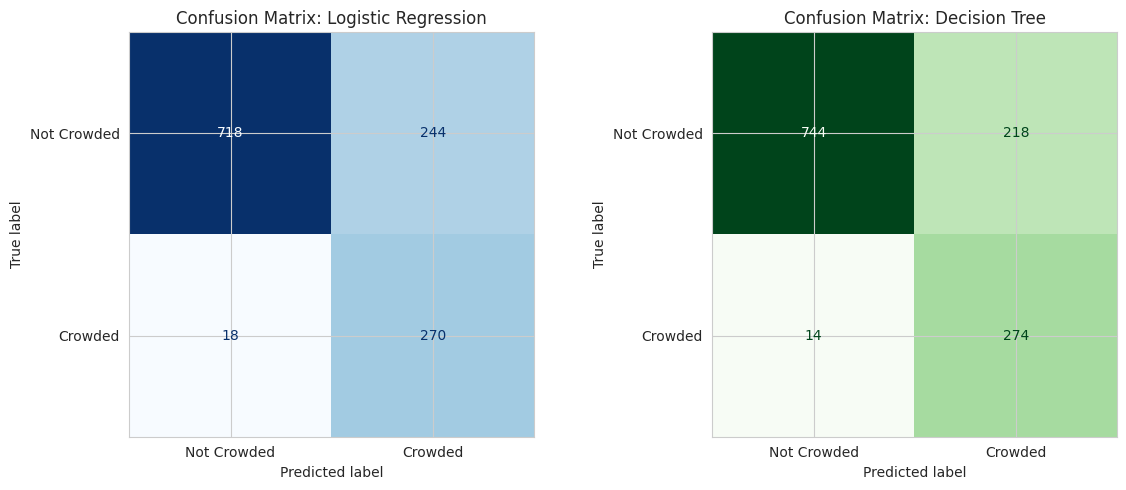

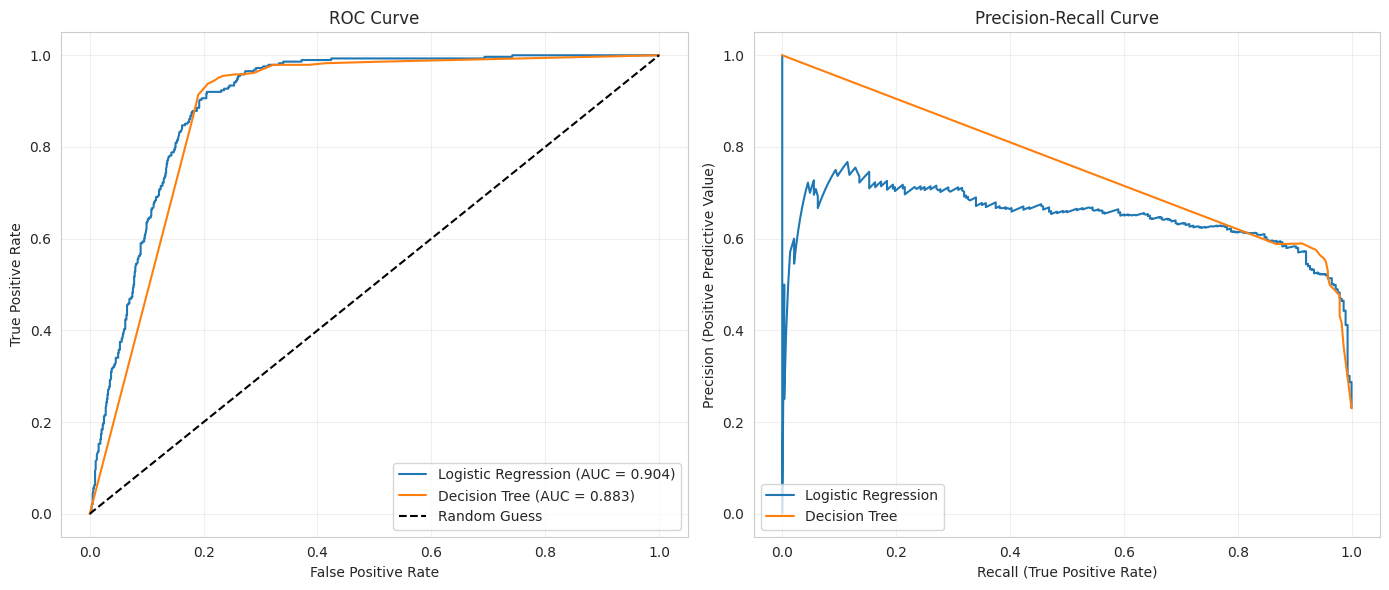

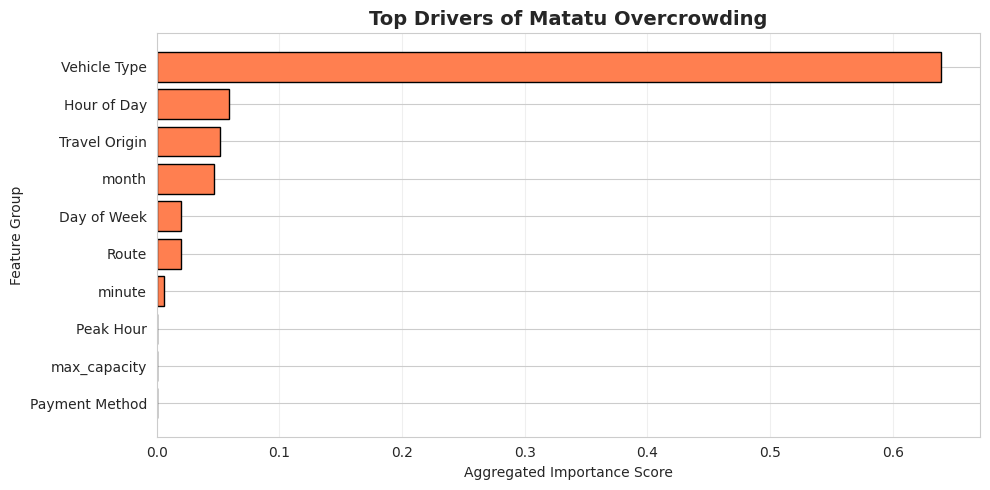

In [ ]:
df = pd.read_csv('matatu_merged_clean.csv')

cols_to_drop = ['ride_id', 'timestamp_bin', 'seats_sold', 'occupancy_rate', 'is_overcrowded']
y = df['is_overcrowded']
X_raw = df.drop(columns=cols_to_drop)

X = pd.get_dummies(X_raw, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- 5-Fold Cross Validation (Robustness Check) ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
tree_clf = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

cv_log = cross_val_score(log_reg, X_train, y_train, cv=cv, scoring='f1')
cv_tree = cross_val_score(tree_clf, X_train, y_train, cv=cv, scoring='f1')

print(f"Logistic Regression CV F1 Score: {cv_log.mean():.4f} (+/- {cv_log.std() * 2:.4f})")
print(f"Decision Tree CV F1 Score:       {cv_tree.mean():.4f} (+/- {cv_tree.std() * 2:.4f})\n")

log_reg.fit(X_train, y_train)
tree_clf.fit(X_train, y_train)

log_preds = log_reg.predict(X_test)
log_probs = log_reg.predict_proba(X_test)[:, 1]

tree_preds = tree_clf.predict(X_test)
tree_probs = tree_clf.predict_proba(X_test)[:, 1]

print("=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===")
print(classification_report(y_test, log_preds))

print("=== DECISION TREE CLASSIFICATION REPORT ===")
print(classification_report(y_test, tree_preds))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, log_preds)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Not Crowded', 'Crowded'])
disp_log.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix: Logistic Regression')

cm_tree = confusion_matrix(y_test, tree_preds)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Not Crowded', 'Crowded'])
disp_tree.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix: Decision Tree')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_probs)

axes[0].plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, log_probs):.3f})')
axes[0].plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {roc_auc_score(y_test, tree_probs):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

prec_log, rec_log, _ = precision_recall_curve(y_test, log_probs)
prec_tree, rec_tree, _ = precision_recall_curve(y_test, tree_probs)

axes[1].plot(rec_log, prec_log, label='Logistic Regression')
axes[1].plot(rec_tree, prec_tree, label='Decision Tree')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall (True Positive Rate)')
axes[1].set_ylabel('Precision (Positive Predictive Value)')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

importances = tree_clf.feature_importances_
feature_names = X.columns

grouped_importances = {}

for name, imp in zip(feature_names, importances):
    if name in ['centroid_lat', 'centroid_lon', 'gis_missing', 'route_count']:
        continue

    base_name = name
    if 'route_' in name: base_name = 'Route'
    elif 'travel_from_' in name: base_name = 'Travel Origin'
    elif 'day_of_week_' in name: base_name = 'Day of Week'
    elif 'car_type_' in name: base_name = 'Vehicle Type'
    elif 'payment_method_' in name: base_name = 'Payment Method'
    elif name == 'hour': base_name = 'Hour of Day'
    elif name == 'is_peak': base_name = 'Peak Hour'

    grouped_importances[base_name] = grouped_importances.get(base_name, 0) + imp

fi_df = pd.DataFrame(list(grouped_importances.items()), columns=['Feature', 'Importance'])
top_features = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(top_features['Feature'], top_features['Importance'], color='coral', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top Drivers of Matatu Overcrowding', fontsize=14, fontweight='bold')
plt.xlabel('Aggregated Importance Score')
plt.ylabel('Feature Group')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


 Member 3: Statistical & Text Visualizer

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('matatu_merged_clean.csv')
print(df.shape)
df.head()

(6249, 19)


,ride_id,route,travel_from,timestamp_bin,hour,minute,day_of_week,month,car_type,payment_method,is_peak,seats_sold,max_capacity,occupancy_rate,is_overcrowded,route_count,centroid_lat,centroid_lon,gis_missing
0,1442,Mombasa Road,Migori,2017-10-17 07:00:00,7,15,Tuesday,10,Bus,Mpesa,1,1,49,0.020408,0,8.0,-1.380190,36.896275,False
1,14304,Mombasa Road,Kisii,2017-11-14 05:00:00,5,10,Tuesday,11,Bus,Mpesa,1,1,49,0.020408,0,8.0,-1.380190,36.896275,False
2,5437,Mombasa Road,Migori,2017-11-19 07:00:00,7,12,Sunday,11,Bus,Mpesa,1,1,49,0.020408,0,8.0,-1.380190,36.896275,False
3,5710,Ngong Road,Keroka,2017-11-26 07:00:00,7,5,Sunday,11,Bus,Mpesa,1,1,49,0.020408,0,20.0,-1.324771,36.742868,False
4,13761,Mombasa Road,Kisii,2017-11-27 05:00:00,5,0,Monday,11,shuttle,Mpesa,1,2,11,0.181818,0,8.0,-1.380190,36.896275,False


### 1. Correlation Heatmap
Numeric ride features against `is_overcrowded` and `occupancy_rate`. `seats_sold` and `occupancy_rate` are excluded from any *modeling* feature matrix (leakage, per Member 1's note) but are kept here for the visualization since this is exploratory, not a feature matrix.

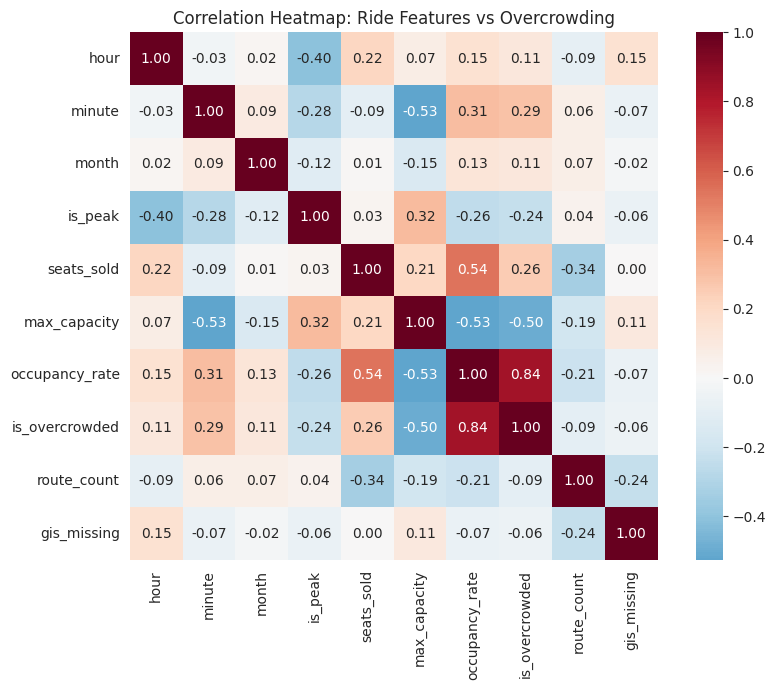

In [ ]:
corr_cols = ['hour', 'minute', 'month', 'is_peak', 'seats_sold', 'max_capacity',
             'occupancy_rate', 'is_overcrowded', 'route_count', 'gis_missing']
corr_df = df[corr_cols].copy()
corr_df['gis_missing'] = corr_df['gis_missing'].astype(int)
corr = corr_df.corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Heatmap: Ride Features vs Overcrowding')
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=150)
plt.show()

### 2. Peak-Hour Overcrowding
Overcrowding rate by hour of day, with the overall dataset average (23%) marked for reference.

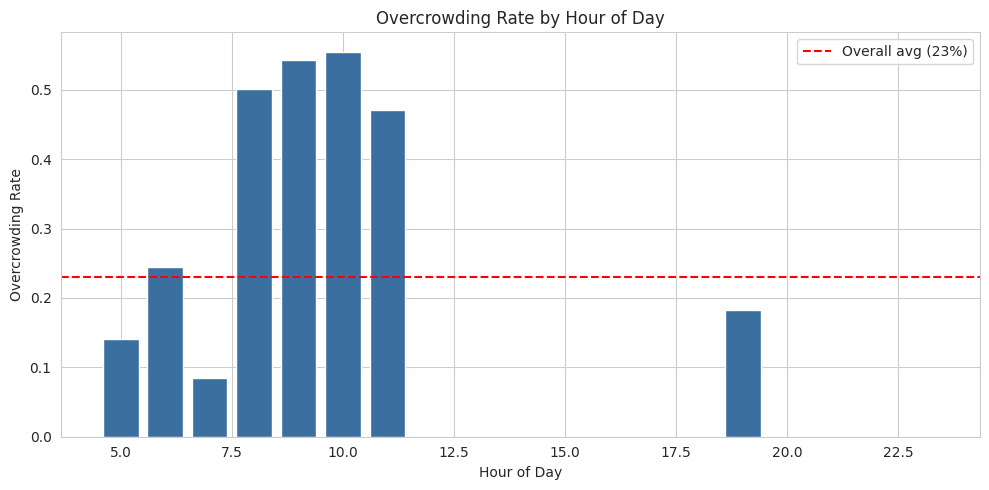

In [ ]:
hourly = df.groupby('hour')['is_overcrowded'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.bar(hourly['hour'], hourly['is_overcrowded'], color='#3b6fa0')
plt.axhline(df['is_overcrowded'].mean(), color='red', linestyle='--', label='Overall avg (23%)')
plt.xlabel('Hour of Day')
plt.ylabel('Overcrowding Rate')
plt.title('Overcrowding Rate by Hour of Day')
plt.legend()
plt.tight_layout()
plt.savefig('peak_hour.png', dpi=150)
plt.show()

### 3. Overcrowding by Corridor
Directly complements Member 2's map heatmaps — same corridors, quantified. Mombasa Road stands out sharply.

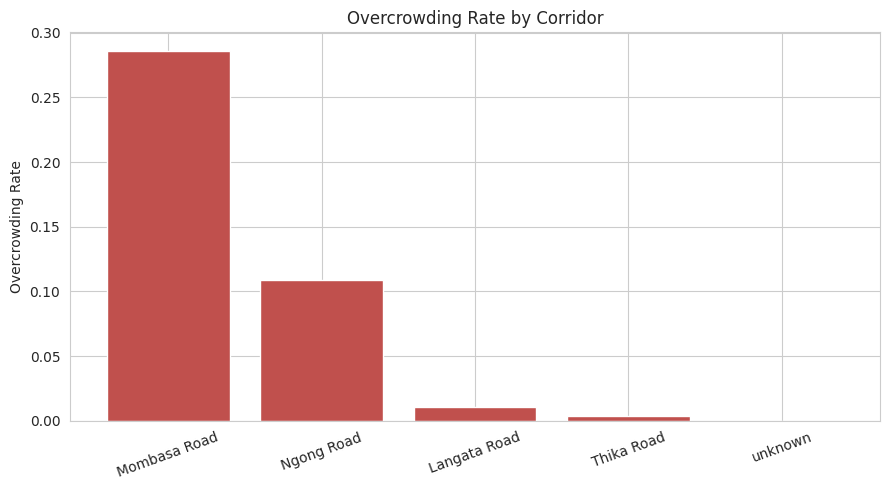

,route,mean,count
1,Mombasa Road,0.286007,4888
2,Ngong Road,0.108434,332
0,Langata Road,0.010582,378
3,Thika Road,0.003472,576
4,unknown,0.000000,75


In [ ]:
route_rate = df.groupby('route')['is_overcrowded'].agg(['mean','count']).reset_index()
route_rate = route_rate.sort_values('mean', ascending=False)

plt.figure(figsize=(9,5))
plt.bar(route_rate['route'], route_rate['mean'], color='#c0504d')
plt.ylabel('Overcrowding Rate')
plt.title('Overcrowding Rate by Corridor')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('corridor.png', dpi=150)
plt.show()

route_rate

### 4. Day of Week × Peak/Off-Peak
Where in the week overcrowding concentrates, split by peak vs off-peak travel.

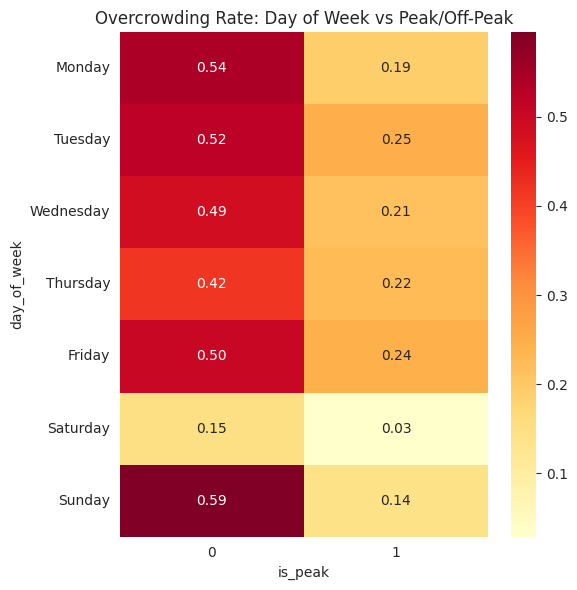

In [ ]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.pivot_table(index='day_of_week', columns='is_peak', values='is_overcrowded', aggfunc='mean')
pivot = pivot.reindex(day_order)

plt.figure(figsize=(6,6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Overcrowding Rate: Day of Week vs Peak/Off-Peak')
plt.xlabel('is_peak')
plt.tight_layout()
plt.savefig('day_peak.png', dpi=150)
plt.show()

### 5. Bonus Panel — Waze Driver Behaviour (substitute for text/sentiment chart)

`waze_dataset.csv` is a generic app-usage/churn dataset (not Nairobi-specific, no text). It's used here only as a rough behavioural reference — does more frequent driving relate to app retention — standing in for the tweet sentiment chart that couldn't be built. This is flagged as a substitution in the report, not presented as equivalent analysis.

/tmp/ipykernel_1902/407111064.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=waze_clean, x='label', y='driving_days', palette=['#3b6fa0','#c0504d'])


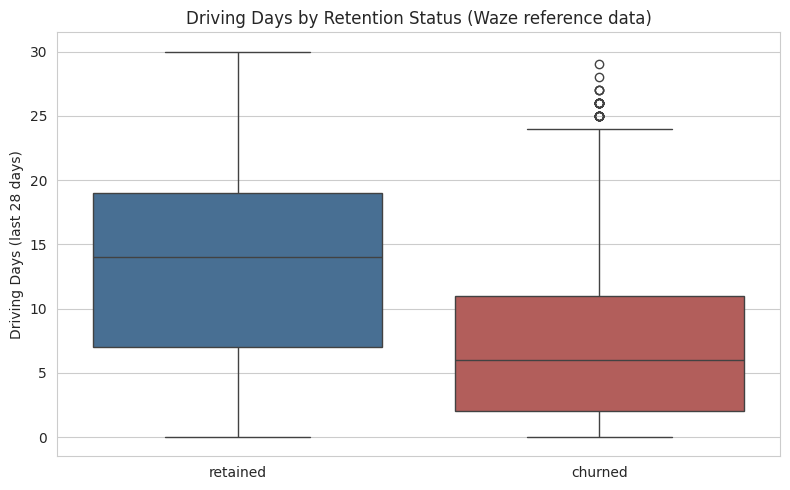

In [ ]:
waze = pd.read_csv('waze_dataset.csv')
waze_clean = waze.dropna(subset=['label'])

plt.figure(figsize=(8,5))
sns.boxplot(data=waze_clean, x='label', y='driving_days', palette=['#3b6fa0','#c0504d'])
plt.title('Driving Days by Retention Status (Waze reference data)')
plt.xlabel('')
plt.ylabel('Driving Days (last 28 days)')
plt.tight_layout()
plt.savefig('waze_bonus.png', dpi=150)
plt.show()